# Modele de regression avance — log_roi
Pipeline complet : baselines, comparatif de modeles, tuning, interpretabilite SHAP, sauvegarde.

**Prerequis** : `pip install xgboost lightgbm shap` (a ajouter dans pyproject.toml).

## 1. Chargement des donnees et split

In [1]:
import sys
sys.path.append("../src")

import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

from boxoffice.modeling.features_ml import load_model_data, NUMERIC_FEATURES
from boxoffice import config

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

X, y_class, y_reg, feature_names = load_model_data()
print(f"X: {X.shape}, y_reg: {y_reg.shape}")
print(f"Moyenne reelle log_roi: {y_reg.mean():.3f}, ecart-type: {y_reg.std():.3f}")

[features_ml] 5 lignes avec NaN residuel exclues.
X: (9263, 36), y_reg: (9263,)
Moyenne reelle log_roi: 0.304, ecart-type: 1.741


In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=RANDOM_STATE
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (7410, 36), Test: (1853, 36)


## 2. Fonction d'evaluation commune
Toutes les metriques sont calculees de la meme facon pour chaque modele, y compris un
MAE relatif (MAE / moyenne reelle) utile car log_roi peut etre proche de 0.

In [3]:
results = []

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, fitted=False):
    if not fitted:
        model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    r2 = r2_score(y_te, y_pred)
    rmse = np.sqrt(mean_squared_error(y_te, y_pred))
    mae = mean_absolute_error(y_te, y_pred)
    mae_relative = mae / abs(y_te.mean())

    results.append({
        "modele": name, "R2": r2, "RMSE": rmse, "MAE": mae, "MAE_relatif": mae_relative
    })
    print(f"{name:25s} R2={r2:.3f}  RMSE={rmse:.3f}  MAE={mae:.3f}  MAE_rel={mae_relative:.3f}")
    return model, y_pred

## 3. Baselines 
Sans elles, impossible de savoir si un modele complexe apporte reellement du signal.

In [4]:
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()
X_train_scaled[NUMERIC_FEATURES] = scaler.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled[NUMERIC_FEATURES] = scaler.transform(X_test[NUMERIC_FEATURES])

dummy = DummyRegressor(strategy="mean")
_ = evaluate_model("Dummy (moyenne)", dummy, X_train_scaled, y_train, X_test_scaled, y_test)

linreg = LinearRegression()
_ = evaluate_model("Regression lineaire", linreg, X_train_scaled, y_train, X_test_scaled, y_test)

Dummy (moyenne)           R2=-0.000  RMSE=1.729  MAE=1.259  MAE_rel=4.259
Regression lineaire       R2=0.140  RMSE=1.603  MAE=1.149  MAE_rel=3.885


## 4. Modeles avances en comparatif
Meme split train/test, meme jeu de features. Ridge/Lasso regularisent la lineaire ;
Random Forest, Gradient Boosting, XGBoost et LightGBM capturent des relations non-lineaires
et des interactions entre variables (ex. budget x genre) sans les specifier manuellement.

In [5]:
ridge = Ridge(alpha=1.0, random_state=RANDOM_STATE)
_ = evaluate_model("Ridge", ridge, X_train_scaled, y_train, X_test_scaled, y_test)

lasso = Lasso(alpha=0.01, random_state=RANDOM_STATE)
_ = evaluate_model("Lasso", lasso, X_train_scaled, y_train, X_test_scaled, y_test)

Ridge                     R2=0.140  RMSE=1.603  MAE=1.148  MAE_rel=3.884
Lasso                     R2=0.132  RMSE=1.611  MAE=1.150  MAE_rel=3.890


In [6]:
# Les modeles a base d'arbres n'ont pas besoin de standardisation : on utilise X brut
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=RANDOM_STATE, n_jobs=-1)
rf_fitted, _ = evaluate_model("Random Forest", rf, X_train, y_train, X_test, y_test)

gbr = GradientBoostingRegressor(n_estimators=300, max_depth=3, learning_rate=0.05, random_state=RANDOM_STATE)
gbr_fitted, _ = evaluate_model("Gradient Boosting", gbr, X_train, y_train, X_test, y_test)

Random Forest             R2=0.142  RMSE=1.602  MAE=1.148  MAE_rel=3.883
Gradient Boosting         R2=0.151  RMSE=1.594  MAE=1.145  MAE_rel=3.873


In [7]:
try:
    from xgboost import XGBRegressor
    xgb = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.05,
                        subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1)
    xgb_fitted, _ = evaluate_model("XGBoost", xgb, X_train, y_train, X_test, y_test)
except ImportError:
    print("xgboost non installe -- pip install xgboost")
    xgb_fitted = None

XGBoost                   R2=0.164  RMSE=1.581  MAE=1.134  MAE_rel=3.836


In [8]:
try:
    from lightgbm import LGBMRegressor
    lgbm = LGBMRegressor(n_estimators=300, max_depth=5, learning_rate=0.05,
                          subsample=0.8, colsample_bytree=0.8, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    lgbm_fitted, _ = evaluate_model("LightGBM", lgbm, X_train, y_train, X_test, y_test)
except ImportError:
    print("lightgbm non installe -- pip install lightgbm")
    lgbm_fitted = None

LightGBM                  R2=0.158  RMSE=1.586  MAE=1.137  MAE_rel=3.846


## 5. Tableau comparatif des metriques

                modele     R2   RMSE    MAE  MAE_relatif
0              XGBoost  0.164  1.581  1.134        3.836
1             LightGBM  0.158  1.586  1.137        3.846
2    Gradient Boosting  0.151  1.594  1.145        3.873
3        Random Forest  0.142  1.602  1.148        3.883
4                Ridge  0.140  1.603  1.148        3.884
5  Regression lineaire  0.140  1.603  1.149        3.885
6                Lasso  0.132  1.611  1.150        3.890
7      Dummy (moyenne) -0.000  1.729  1.259        4.259


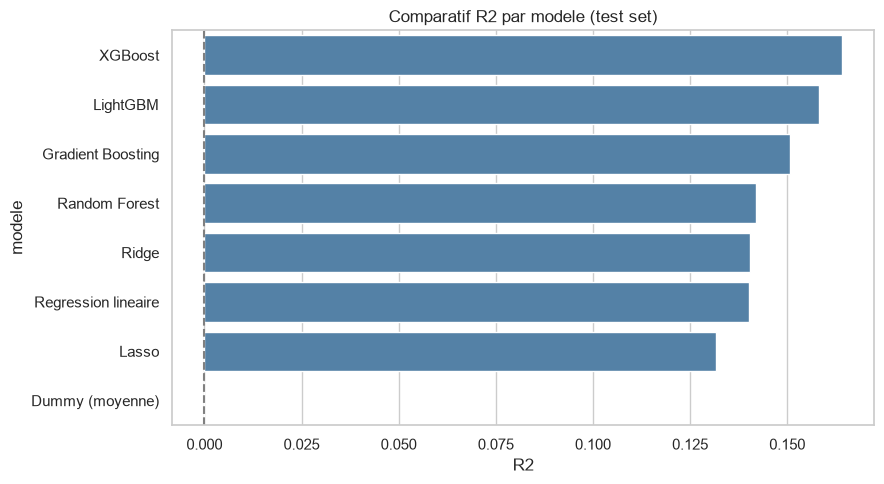

In [9]:
results_df = pd.DataFrame(results).sort_values("R2", ascending=False).reset_index(drop=True)
print(results_df.round(3))

plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x="R2", y="modele", color="steelblue")
plt.title("Comparatif R2 par modele (test set)")
plt.axvline(0, color="grey", linestyle="--")
plt.tight_layout()
plt.show()

## 6. Selection du meilleur modele et tuning
On retient le meilleur candidat du comparatif ci-dessus (a ajuster selon le resultat reel)
et on affine ses hyperparametres via RandomizedSearchCV avec K-Fold classique
(donnees cross-sectionnelles, pas de serie temporelle -> pas besoin de TimeSeriesSplit).

In [10]:
best_model_name = results_df.iloc[0]["modele"]
print(f"Meilleur modele du comparatif: {best_model_name}")

# Exemple avec LightGBM -- adapter le nom/estimateur si le meilleur modele differe
from lightgbm import LGBMRegressor

param_dist = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [3, 4, 5, 6, -1],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.7, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 1.0],
    "num_leaves": [15, 31, 63],
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1),
    param_distributions=param_dist,
    n_iter=30,
    scoring="r2",
    cv=kfold,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

print(f"\nMeilleurs hyperparametres: {search.best_params_}")
print(f"Meilleur R2 en cross-validation: {search.best_score_:.3f}")

Meilleur modele du comparatif: XGBoost
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Meilleurs hyperparametres: {'subsample': 0.8, 'num_leaves': 31, 'n_estimators': 500, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.6}
Meilleur R2 en cross-validation: 0.204


In [11]:
best_model, y_pred_best = evaluate_model(
    "LightGBM (tune)", search.best_estimator_, X_train, y_train, X_test, y_test, fitted=True
)

LightGBM (tune)           R2=0.165  RMSE=1.580  MAE=1.136  MAE_rel=3.841


## 7. Diagnostic du modele final : predictions vs reel, residus

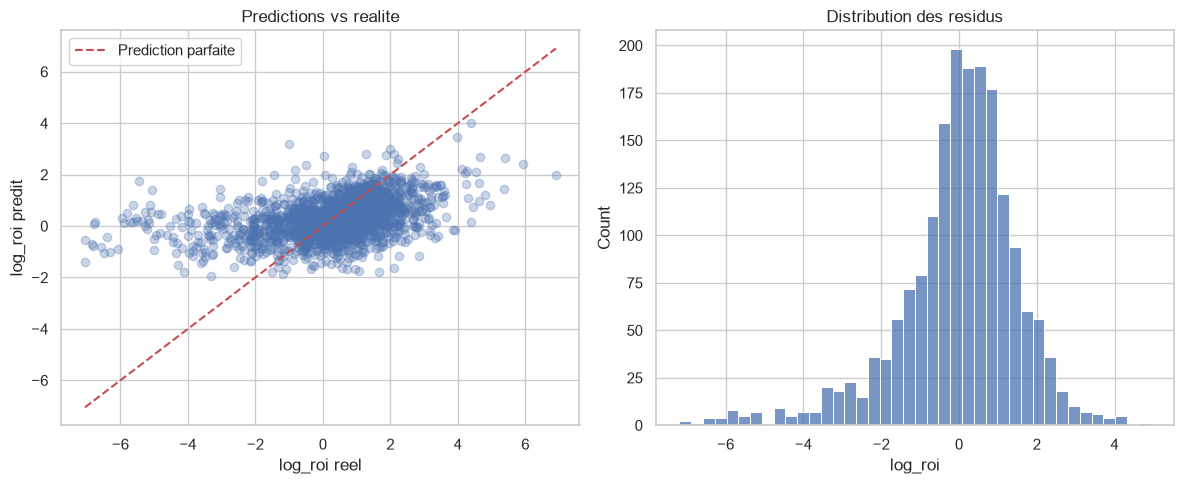

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].scatter(y_test, y_pred_best, alpha=0.3)
lims = [min(y_test.min(), y_pred_best.min()), max(y_test.max(), y_pred_best.max())]
axes[0].plot(lims, lims, "r--", label="Prediction parfaite")
axes[0].set_xlabel("log_roi reel")
axes[0].set_ylabel("log_roi predit")
axes[0].set_title("Predictions vs realite")
axes[0].legend()

residuals = y_test - y_pred_best
sns.histplot(residuals, bins=40, ax=axes[1])
axes[1].set_title("Distribution des residus")
plt.tight_layout()
plt.show()

## 8. Interpretabilite avec SHAP
TreeExplainer decompose chaque prediction en contribution additive de chaque feature,
plus fin que les coefficients d'une regression lineaire car il capture les interactions
et les effets non-lineaires appris par le modele en arbres.

In [13]:
try:
    import shap

    explainer = shap.TreeExplainer(search.best_estimator_)
    shap_values = explainer.shap_values(X_test)

    shap.summary_plot(shap_values, X_test, show=False)
    plt.tight_layout()
    plt.savefig("../data/processed/shap_summary_regression.png", dpi=100, bbox_inches="tight")
    plt.show()
except ImportError:
    print("shap non installe -- pip install shap")

KeyboardInterrupt: 

In [ ]:
try:
    mean_abs_shap = pd.Series(np.abs(shap_values).mean(axis=0), index=feature_names).sort_values(ascending=False)
    print("Top 10 features par importance SHAP moyenne:")
    print(mean_abs_shap.head(10))
except NameError:
    pass

Top 10 features par importance SHAP moyenne:
is_franchise                0.354412
runtime                     0.208957
director_taux_hits_avant    0.204501
n_cast                      0.203902
log_budget                  0.185915
cast_taux_hits_avant        0.129600
age_min                     0.124036
director_films_avant        0.077763
cast_films_avant            0.046242
genre_Drama                 0.037363
dtype: float64


## 9. Sauvegarde des artefacts
Modele final, scaler (utile si un modele lineaire est finalement retenu), liste de features,
et tableau comparatif -- tout ce qu'il faut pour reutiliser ou auditer le modele plus tard.

In [ ]:
import os

MODELS_DIR = config.PROCESSED.parent / "models"
MODELS_DIR.mkdir(parents=True, exist_ok=True)

joblib.dump(search.best_estimator_, MODELS_DIR / "regression_log_roi_best.joblib")
joblib.dump(scaler, MODELS_DIR / "scaler_numeric_features.joblib")

with open(MODELS_DIR / "feature_names.json", "w", encoding="utf-8") as f:
    json.dump(feature_names, f, indent=2)

results_df.to_csv(MODELS_DIR / "regression_comparatif_metrics.csv", index=False)

metadata = {
    "target": "log_roi",
    "best_model": "LightGBM (tune)",
    "best_params": search.best_params_,
    "cv_r2": search.best_score_,
    "test_r2": r2_score(y_test, y_pred_best),
    "test_rmse": float(np.sqrt(mean_squared_error(y_test, y_pred_best))),
    "test_mae": float(mean_absolute_error(y_test, y_pred_best)),
    "n_train": len(X_train),
    "n_test": len(X_test),
    "random_state": RANDOM_STATE,
}
with open(MODELS_DIR / "regression_metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2)

print(f"Artefacts sauvegardes dans {MODELS_DIR}")
print(os.listdir(MODELS_DIR))

Artefacts sauvegardes dans C:\Users\mikoy\Documents\ESIEA-A4\Data-Visualisation\movie-boxoffice-recommender\data\models
['feature_names.json', 'regression_comparatif_metrics.csv', 'regression_log_roi_best.joblib', 'regression_metadata.json', 'scaler_numeric_features.joblib']


## 10. Conclusion

- Le comparatif ci-dessus valide (ou invalide) l'interet des modeles non-lineaires par rapport
  aux baselines Dummy et regression lineaire.
- Le R2 reste probablement modere (succes commercial = phenomene bruite, facteurs hors donnees),
  mais un gain mesurable par rapport a la regression lineaire simple justifie l'usage d'un modele
  plus complexe en production.
- SHAP permet d'expliquer chaque prediction individuelle, utile pour justifier une recommandation
  de production auprès de la direction studio (pas seulement un score, mais un "pourquoi").